# In questo notebook alleneremo un modello a tradurre date in formato testuale in date in formato YYYY-MM-DD

In [2]:
!pip install faker tqdm


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from babel.dates import format_date
from faker import Faker
import random
from tqdm import tqdm
fake = Faker()
Faker.seed(12345)
random.seed(12345)

# Define format of the data we would like to generate
FORMATS = ['short',
           'medium',
           'long',
           'full',
           'full',
           'full',
           'full',
           'full',
           'full',
           'full',
           'full',
           'full',
           'full',
           'd MMM YYY',
           'd MMMM YYY',
           'dd MMM YYY',
           'd MMM, YYY',
           'd MMMM, YYY',
           'dd, MMM YYY',
           'd MM YY',
           'd MMMM YYY',
           'MMMM d YYY',
           'MMMM d, YYY',
           'dd.MM.YY']

LOCALES = ['en_US']

In [2]:
def load_date():
    """
        Loads some fake dates
        :returns: tuple containing human readable string, machine readable string, and date object
    """
    dt = fake.date_object()

    try:
        human_readable = format_date(dt, format=random.choice(FORMATS),  locale='en_US') # locale=random.choice(LOCALES))
        human_readable = human_readable.lower()
        human_readable = human_readable.replace(',','')
        machine_readable = dt.isoformat()

    except AttributeError as e:
        return None, None, None

    return human_readable, machine_readable, dt

In [3]:
def load_dataset(m):
    """
        Loads a dataset with m examples and vocabularies
        # :m: the number of examples to generate
    """

    human_vocab = set()
    machine_vocab = set()
    dataset = []
    Tx = 30


    for i in tqdm(range(m)):
        h, m, _ = load_date()
        if h is not None:
            dataset.append((h, m))

    return dataset

In [4]:
m = 10000
train_dataset_raw = load_dataset(m)
test_dataset_raw = load_dataset(2000)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:00<00:00, 75418.81it/s]


In [5]:
train_dataset_raw[:10]

[('9 may 1998', '1998-05-09'),
 ('10.11.19', '2019-11-10'),
 ('9/10/70', '1970-09-10'),
 ('friday october 24 2025', '2025-10-24'),
 ('monday august 19 2024', '2024-08-19'),
 ('saturday april 28 1990', '1990-04-28'),
 ('thursday january 26 1995', '1995-01-26'),
 ('07 mar 1983', '1983-03-07'),
 ('22 may 1988', '1988-05-22'),
 ('tuesday july 8 2008', '2008-07-08')]

### Definiamo ora la rete RNN Encoder e RNN Decoder

In [6]:
import torch
import torch.nn as nn

class EncoderRNN(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size):
        super(EncoderRNN, self).__init__()
        self.hidden_size = hidden_size

        # Trasforma l'indice del carattere in un vettore denso di dimensione 'embedding_size'
        self.embedding = nn.Embedding(vocab_size, embedding_size)

        # La GRU riceve in ingresso l'embedding e produce/aggiorna lo stato nascosto
        self.gru = nn.GRU(input_size=embedding_size, hidden_size=hidden_size, batch_first=True)

    def forward(self, x):
        # x: (batch_size, seq_len)
        embedded = self.embedding(x) # (batch_size, seq_len, embedding_size)

        # output: tutti gli stati nascosti (batch, seq_len, hidden_size)
        # hidden: l'ultimo stato nascosto (1, batch, hidden_size)
        output, hidden = self.gru(embedded)
        return output, hidden

In [7]:
class SimpleDecoderRNN(nn.Module):
    def __init__(self, output_size, embedding_size, hidden_size, ):
        super(SimpleDecoderRNN, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(output_size, embedding_size)
        self.gru = nn.GRU(input_size=embedding_size, hidden_size=hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden):
        # input_step: (batch_size, 1) - è lo y_{t-1}
        # hidden: lo stato precedente s_{t-1}

        embedded = self.embedding(input_step)
        output, hidden = self.gru(embedded, hidden)
        # output: tutti gli stati nascoti (batch, seq_len, hidden_size)
        # hidden: l'ultimo stato nascosto (1, batch, hidden_size)
        # Predizione del carattere successivo
        prediction = self.out(output.squeeze(1))
        return prediction, hidden

## Creiamo ora il vocabolario

In [8]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class Vocab:
    def __init__(self):
        # Token speciali fondamentali
        self.char2idx = {"<PAD>": 0, "<SOS>": 1, "<EOS>": 2, "<UNK>": 3}
        self.idx2char = {v: k for k, v in self.char2idx.items()}
        self.n_chars = 4

    def add_sentence(self, sentence):
        for char in sentence.lower():
            if char not in self.char2idx:
                self.char2idx[char] = self.n_chars
                self.idx2char[self.n_chars] = char
                self.n_chars += 1

    def encode(self, text, add_sos=False, add_eos=False):
        res = [self.char2idx.get(c, 3) for c in text.lower()]
        if add_sos: res = [1] + res
        if add_eos: res = res + [2]
        return res

    def __len__(self):
        return self.n_chars

# Inizializziamo i vocabolari
input_vocab = Vocab()
output_vocab = Vocab()


for src, trg in train_dataset_raw:
    input_vocab.add_sentence(src)
    output_vocab.add_sentence(trg)

In [9]:
class DateDataset(Dataset):
    def __init__(self, data, input_vocab, output_vocab):
        self.data = data
        self.input_vocab = input_vocab
        self.output_vocab = output_vocab

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        src_str, trg_str = self.data[idx]

        # Trasformiamo in liste di indici
        src_idx = self.input_vocab.encode(src_str, add_eos=True)
        trg_idx = self.output_vocab.encode(trg_str, add_sos=True, add_eos=True)

        return torch.tensor(src_idx), torch.tensor(trg_idx)

In [10]:
#Serve fare il padding delle
def collate_fn(batch):
    # Separiamo sorgenti e target
    src_batch, trg_batch = zip(*batch)

    # Padding automatico con valore 0 (il nostro <PAD>)
    src_padded = pad_sequence(src_batch, batch_first=True, padding_value=0)
    trg_padded = pad_sequence(trg_batch, batch_first=True, padding_value=0)

    return src_padded, trg_padded

# Creazione del DataLoader
train_dataset = DateDataset(train_dataset_raw, input_vocab, output_vocab)
test_dataset = DateDataset(test_dataset_raw, input_vocab, output_vocab)
loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
val_laoder = DataLoader(test_dataset, batch_size=4, shuffle=True, collate_fn=collate_fn)
# Test rapido
for src, trg in loader:
    print(f"Forma batch sorgente: {src.shape}") # (batch, max_src_len)
    print(f"Forma batch target: {trg.shape}")   # (batch, max_trg_len)
    break

Forma batch sorgente: torch.Size([4, 22])
Forma batch target: torch.Size([4, 12])


In [11]:
# Dimensioni basate sui vocabolari che abbiamo creato prima
INPUT_DIM = input_vocab.n_chars   # Numero di caratteri unici nel sorgente, sarebbe la vocab_size
OUTPUT_DIM = output_vocab.n_chars # Numero di caratteri unici nel target

# Iperparametri del modello
ENC_EMB_DIM = 32   # Dimensione embedding caratteri (piccola è ok per i caratteri)
DEC_EMB_DIM = 32
HID_DIM = 128      # Dimensione della memoria (stato nascosto)

In [12]:
output_vocab.char2idx

{'<PAD>': 0,
 '<SOS>': 1,
 '<EOS>': 2,
 '<UNK>': 3,
 '1': 4,
 '9': 5,
 '8': 6,
 '-': 7,
 '0': 8,
 '5': 9,
 '2': 10,
 '7': 11,
 '4': 12,
 '6': 13,
 '3': 14}

In [13]:

# Ignoriamo il padding nel calcolo della perdita
criterion = nn.CrossEntropyLoss(ignore_index=input_vocab.char2idx["<PAD>"])
# Creiamo i componenti
enc_simple = EncoderRNN(INPUT_DIM, ENC_EMB_DIM, HID_DIM)
dec_simple = SimpleDecoderRNN(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
enc_simple.to(device)
dec_simple.to(device)
# Ottimizzatori (uno per ogni parte del modello o uno unico)
encoder_optimizer = torch.optim.Adam(enc_simple.parameters(), lr=0.001)
decoder_optimizer = torch.optim.Adam(dec_simple.parameters(), lr=0.001)

In [14]:
def train_step(input_tensor, target_tensor, encoder, decoder,
               encoder_optimizer, decoder_optimizer, criterion, device, max_length=20, ):

    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    batch_size = input_tensor.size(0)
    target_length = target_tensor.size(1)
    loss = 0 
    

    # --- ENCODER ---
    # Otteniamo l'ultimo stato nascosto (il "collo di bottiglia")
    _, encoder_hidden = encoder(input_tensor)

    # --- DECODER ---
    # Il primo input è il token <SOS> per tutto il batch
    decoder_input = torch.tensor([[output_vocab.char2idx["<SOS>"]]] * batch_size).to(device)
    decoder_hidden = encoder_hidden # Inizializziamo il decoder con la memoria dell'encoder

    for di in range(1, target_length):
        #Faccio uno steo del decoder
        output, decoder_hidden = decoder(decoder_input, decoder_hidden)

        # Calcolo della perdita confrontando con il carattere reale del target
        loss += criterion(output, target_tensor[:, di])

        decoder_input = target_tensor[:, di].unsqueeze(1)


    # Backpropagation
    loss.backward()

    # Gradient Clipping (opzionale ma consigliato per le RNN per evitare esplosioni)
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)

    encoder_optimizer.step()
    decoder_optimizer.step()

    return loss.item() / target_length

In [15]:
def evaluate_accuracy(encoder, decoder, dataloader, output_vocab, device, max_len=20):
    encoder.eval()
    decoder.eval()
    
    total_correct = 0
    total_samples = 0
    sos_idx = output_vocab.char2idx["<SOS>"]
    eos_idx = output_vocab.char2idx["<EOS>"]
    pad_idx = output_vocab.char2idx["<PAD>"]

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)
            batch_size = src.size(0)
            
            # 1. Encoding
            encoder_outputs, hidden = encoder(src)
            
            # 2. Decoding Autoregressivo (No Teacher Forcing)
            decoder_input = torch.tensor([[sos_idx]] * batch_size).to(device)
            
            # Matrice per salvare i risultati del batch
            # Inizializziamo con PAD per sicurezza
            batch_preds = torch.full((batch_size, max_len), pad_idx).to(device)
            
            for t in range(1, max_len):
                output, hidden = decoder(decoder_input, hidden)
                
                # Prendiamo il carattere più probabile
                topi = output.argmax(1) 
                batch_preds[:, t] = topi
                
                # Il carattere predetto diventa il prossimo input
                decoder_input = topi.unsqueeze(1)
            
            # 3. Calcolo Exact Match
            # Puliamo i target e le predizioni ignorando SOS e confrontando fino a EOS
            for i in range(batch_size):
                # Trasformiamo i tensori in liste di indici per un confronto più semplice
                pred_list = batch_preds[i, 1:].tolist()
                trg_list = trg[i, 1:].tolist()
                
                # Tagliamo la sequenza al primo EOS trovato
                if eos_idx in pred_list:
                    pred_list = pred_list[:pred_list.index(eos_idx)]
                if eos_idx in trg_list:
                    trg_list = trg_list[:trg_list.index(eos_idx)]
                
                # Se la lista pulita è identica, la frase è corretta
                if pred_list == trg_list:
                    total_correct += 1
                total_samples += 1

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [ ]:
epochs = 15
for epoch in range(1, epochs + 1):
    total_loss = 0
    total_correct = 0
    total_samples = 0
    enc_simple.train()
    dec_simple.train()
    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)

        loss = train_step(src, trg, enc_simple, dec_simple,
                                   encoder_optimizer, decoder_optimizer,
                                   criterion, device, len(output_vocab))

        total_loss += loss
        total_samples += src.size(0)

    test_accuracy = evaluate_accuracy(enc_simple, dec_simple, val_laoder, output_vocab, device)
    if epoch % 1 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss/len(loader):.4f} | Accuracy: {test_accuracy:.2f}%")

Epoch 1 | Loss: 0.5994 | Accuracy: 0.35%
Epoch 2 | Loss: 0.4239 | Accuracy: 2.55%


In [23]:
def predict_simple(sentence, encoder, decoder, input_vocab, output_vocab, device, max_len=20):
    # 1. Modalità valutazione (disattiva dropout e simili)
    encoder.eval()
    decoder.eval()

    with torch.no_grad():
        # 2. Trasformiamo la stringa in input in un tensore di indici
        # Aggiungiamo il token <EOS> alla fine della stringa sorgente
        src_indices = input_vocab.encode(sentence, add_eos=True)
        src_tensor = torch.tensor(src_indices).unsqueeze(0).to(device) # Shape: [1, seq_len]

        # 3. Passaggio nell'Encoder
        # Per la SimpleRNN ci serve solo l'ultimo hidden state
        encoder_outputs, hidden = encoder(src_tensor)

        # 4. Inizializziamo il Decoder con il token <SOS>
        # Il decoder_input deve essere sul device corretto
        decoder_input = torch.tensor([[output_vocab.char2idx["<SOS>"]]]).to(device)

        # Inizializziamo il decoder_hidden con l'ultimo stato dell'encoder
        decoder_hidden = hidden

        translated_chars = []

        # 5. Ciclo di generazione carattere per carattere
        for i in range(max_len):
            # Passo del decoder
            output, decoder_hidden = decoder(decoder_input, decoder_hidden)

            # Prendiamo il carattere con la probabilità più alta (argmax)
            topi = output.argmax(1)
            char = output_vocab.idx2char[topi.item()]

            # Se il modello predice <EOS>, la traduzione è finita
            if char == "<EOS>":
                break

            translated_chars.append(char)

            # Importante: la predizione attuale diventa l'input per il prossimo passo
            decoder_input = topi.unsqueeze(1)

    return "".join(translated_chars)

In [26]:
# Esempi di test
date_test = "saturday june 27 03"
risultato = predict_simple(date_test, enc_simple, dec_simple, input_vocab, output_vocab, device)

print(f"Input: {date_test}")
print(f"Output del modello: {risultato}")

Input: saturday june 27 03
Output del modello: 2003-06-27


## Implementiamo ora la rete con l'attenzione

In [32]:
class BidirectionalEncoder(nn.Module):
    def __init__(self, vocab_size, embedding_size, hidden_size):
        super(BidirectionalEncoder, self).__init__()
        self.hidden_size = hidden_size
        self.embedding = nn.Embedding(vocab_size, embedding_size)

        # Gru Bidirezionale
        self.gru = nn.GRU(embedding_size, hidden_size, batch_first=True, bidirectional=True)

        # Layer per comprimere i due stati (fwd + bwd) in uno solo per il decoder
        self.fc = nn.Linear(hidden_size * 2, hidden_size)

    def forward(self, x):
        embedded = self.embedding(x)

        # outputs: [batch, seq_len, hidden_size * 2]
        # hidden: [2, batch, hidden_size] (il primo è forward, il secondo è backward)
        outputs, hidden = self.gru(embedded) #Mi serve per calcolare s<0>

        # Concateniamo i due stati nascosti finali e li passiamo attraverso la FC
        # hidden[0,:,:] è l'ultimo stato forward, hidden[1,:,:] è l'ultimo backward
        combined_hidden = torch.cat((hidden[0,:,:], hidden[1,:,:]), dim=1)
        merged_hidden = torch.tanh(self.fc(combined_hidden)).unsqueeze(0)

        # merged_hidden: [1, batch, hidden_size]
        return outputs, merged_hidden

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class AttentionDecoder(nn.Module):
    def __init__(self, output_size, embedding_size, hidden_size):
        super(AttentionDecoder, self).__init__()
        self.hidden_size = hidden_size

        # 1. Layer di base
        self.embedding = nn.Embedding(output_size, embedding_size)

        # 2. Layer per calcolare l'Attention (Bahdanau)
        # Riceve in input la concatenazione di s_{t-1} e a_i
        self.attn = nn.Linear(hidden_size * 3, hidden_size) #calcola il nostr vettore e delle slides
        self.v = nn.Linear(hidden_size, 1, bias=False)

        # 3. La GRU
        # L'input è (Embedding di y_{t-1} + Context Vector)
        self.gru = nn.GRU(embedding_size + hidden_size * 2, hidden_size, batch_first=True)

        # 4. Layer di Output
        self.out = nn.Linear(hidden_size, output_size)

    def forward(self, input_step, hidden, encoder_outputs):
        # input_step: [batch_size, 1] (y_{t-1})
        # hidden: [1, batch_size, hidden_size] (s_{t-1})
        # encoder_outputs: [batch_size, seq_len, hidden_size] (tutti gli h_i)


        src_len = encoder_outputs.size(1)

        # --- STEP 1: CALCOLO DEI PESI DI ATTENZIONE (Alpha) ---
        #Le RNN di PyTorch restituiscono lo stato nascosto con il batch in seconda posizione.
        # Trasformiamo [1, batch_size, hidden_size] in [batch_size, 1, hidden_size].
        # Ripetiamo lo stato nascosto precedente per ogni step dell'encoder
        # hidden_rep: [batch_size, src_len, hidden_size]
        hidden_rep = hidden.permute(1, 0, 2).repeat(1, src_len, 1)

        # Calcoliamo l'energia: tanh(W_s * s_{t-1} + W_h * h_i)
        # Per calcolare gli alpha devo calcolare le e con una rete neurale a un layer con tanh
        # energy size = [batch_size, src_len, hidden_size]
        energy = torch.tanh(self.attn(torch.cat((hidden_rep, encoder_outputs), dim=2)))

        # Calcoliamo gli score: v^T * energia. squeeze(2) elimina la dimensione all'indice 2
        attention_scores = self.v(energy).squeeze(2) # [batch_size, src_len]

        # Softmax per ottenere pesi che sommano a 1
        alphas = F.softmax(attention_scores, dim=1).unsqueeze(1) # [batch_size, 1, src_len]

        # --- STEP 2: CONTEXT VECTOR ---
        # Moltiplicazione tra pesi e stati dell'encoder
        # [batch, 1, src_len] * [batch, src_len, hid] -> [batch, 1, hid] for index in range(bacth_size) - alphas[i].dot( encoder_outputs[i)
        """torch.bmm sta per Batch Matrix-Matrix product. È il comando che permette di moltiplicare "a pacchetti" intere pile di matrici in un colpo solo, ed è il motore che rende l'Attention Mechanism così veloce su GPU."""
        context = torch.bmm(alphas, encoder_outputs)

        # --- STEP 3: AGGIORNAMENTO GRU ---
        embedded = self.embedding(input_step) # [batch_size, 1, embedding_size]

        # Concateniamo l'embedding e il contesto
        gru_input = torch.cat((embedded, context), dim=2) # [batch, 1, emb + hid]

        output, hidden = self.gru(gru_input, hidden)

        # --- STEP 4: PREDIZIONE ---
        prediction = self.out(output.squeeze(1)) # [batch_size, output_size]

        # Restituiamo anche alphas per poter disegnare la Heatmap
        return prediction, hidden, alphas

## Definisco il nuovo step di training

In [37]:
def train_step_attention(input_tensor, target_tensor, encoder, decoder,
                         encoder_optimizer, decoder_optimizer, criterion, device):

    # 1. Reset dei gradienti e modalità training
    encoder.train()
    decoder.train()
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()

    batch_size = input_tensor.size(0)
    target_length = target_tensor.size(1)
    loss = 0


    all_predictions = torch.zeros(batch_size, target_length).to(device)

    # --- ENCODER ---
    # Qui otteniamo TUTTI gli stati (encoder_outputs) per l'attention
    encoder_outputs, encoder_hidden = encoder(input_tensor)

    # --- DECODER ---
    # Inizializziamo con <SOS>
    decoder_input = torch.tensor([[output_vocab.char2idx["<SOS>"]]] * batch_size).to(device)

    # Lo stato iniziale del decoder è l'ultimo dell'encoder
    decoder_hidden = encoder_hidden

    for di in range(1, target_length):
        # NOTA: Qui passiamo anche encoder_outputs
        # Il decoder restituisce: predizione, nuovo hidden, e pesi attention (alphas)
        output, decoder_hidden, alphas = decoder(decoder_input, decoder_hidden, encoder_outputs)



        # Calcolo della perdita
        loss += criterion(output, target_tensor[:, di])

        # Teacher Forcing al 100%: l'input successivo è la verità del dataset
        decoder_input = target_tensor[:, di].unsqueeze(1)

    # --- BACKPROPAGATION ---
    loss.backward()

    # Clipping per evitare che i gradienti "esplodano" (molto comune nelle RNN)
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), 1.0)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), 1.0)

    encoder_optimizer.step()
    decoder_optimizer.step()


    return loss.item() / target_length

In [38]:
def evaluate_accuracy_attn(encoder, decoder, dataloader, output_vocab, device, max_len=20):
    encoder.eval()
    decoder.eval()

    total_correct = 0
    total_samples = 0
    sos_idx = output_vocab.char2idx["<SOS>"]
    eos_idx = output_vocab.char2idx["<EOS>"]
    pad_idx = output_vocab.char2idx["<PAD>"]

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)
            batch_size = src.size(0)

            # 1. Encoding
            encoder_outputs, hidden = encoder(src)

            # 2. Decoding Autoregressivo (No Teacher Forcing)
            decoder_input = torch.tensor([[sos_idx]] * batch_size).to(device)

            batch_preds = torch.full((batch_size, max_len), pad_idx).to(device)

            for t in range(1, max_len):

                res = decoder(decoder_input, hidden, encoder_outputs)
                output, hidden = res[0], res[1]

                topi = output.argmax(1)
                batch_preds[:, t] = topi

                decoder_input = topi.unsqueeze(1)


            # 3. Calcolo Exact Match
            for i in range(batch_size):
                pred_list = batch_preds[i, 1:].tolist()
                trg_list = trg[i, 1:].tolist()

                if eos_idx in pred_list:
                    pred_list = pred_list[:pred_list.index(eos_idx)]
                else:
                    # Rimuoviamo eventuali PAD rimasti se EOS non è stato predetto
                    pred_list = [idx for idx in pred_list if idx != pad_idx]

                if eos_idx in trg_list:
                    trg_list = trg_list[:trg_list.index(eos_idx)]
                else:
                    trg_list = [idx for idx in trg_list if idx != pad_idx]

                if pred_list == trg_list:
                    total_correct += 1
                total_samples += 1

    accuracy = (total_correct / total_samples) * 100
    return accuracy

In [41]:
enc_attn = BidirectionalEncoder(INPUT_DIM, ENC_EMB_DIM, HID_DIM).to(device)
dec_attn = AttentionDecoder(OUTPUT_DIM, DEC_EMB_DIM, HID_DIM).to(device)

optimizer_enc = torch.optim.Adam(enc_attn.parameters(), lr=0.001)
optimizer_dec = torch.optim.Adam(dec_attn.parameters(), lr=0.001)

for epoch in range(1, 10):
    epoch_loss = 0
    epoch_correct = 0

    for src, trg in loader:
        src, trg = src.to(device), trg.to(device)

        loss = train_step_attention(src, trg, enc_attn, dec_attn,
                                    optimizer_enc, optimizer_dec, criterion, device)
        epoch_loss += loss


    # Valutazione sul validation set (importante!)
    val_acc = evaluate_accuracy_attn(enc_attn, dec_attn, val_laoder, output_vocab, device)

    if epoch % 2 == 1:
        print(f"Epoca {epoch} | Loss: {epoch_loss/len(loader):.4f} | Val Accuracy: {val_acc:.2f}%")

Epoca 1 | Loss: 0.1170 | Val Accuracy: 99.30%
Epoca 3 | Loss: 0.0038 | Val Accuracy: 99.55%


KeyboardInterrupt: 

In [42]:
def predict_attn(sentence, encoder, decoder, input_vocab, output_vocab, device, max_length=20):
    with torch.no_grad():
        encoder.eval()
        decoder.eval()

        # 1. Pre-processing dell'input
        input_indices = input_vocab.encode(sentence, add_eos=True)
        input_tensor = torch.tensor(input_indices).unsqueeze(0).to(device)

        # 2. Encoding
        encoder_outputs, encoder_hidden = encoder(input_tensor)

        # 3. Preparazione Decoder
        decoder_input = torch.tensor([[output_vocab.char2idx["<SOS>"]]]).to(device)
        decoder_hidden = encoder_hidden

        decoded_chars = []
        # Qui salviamo i pesi dell'attenzione per ogni step
        attentions = torch.zeros(max_length, len(input_indices))

        for di in range(max_length):
            # Passo del decoder
            output, decoder_hidden, attention = decoder(decoder_input, decoder_hidden, encoder_outputs)

            # Salviamo i pesi dell'attenzione (attention shape: [1, 1, src_len])
            attentions[di] = attention.squeeze().cpu()

            # Prendiamo il carattere più probabile
            topv, topi = output.data.topk(1)
            char = output_vocab.idx2char[topi.item()]

            if char == '<EOS>':
                break
            else:
                decoded_chars.append(char)

            decoder_input = topi.detach()

        return "".join(decoded_chars), attentions[:len(decoded_chars), :]

In [44]:
train_dataset_raw[:20]

[('9 may 1998', '1998-05-09'),
 ('10.11.19', '2019-11-10'),
 ('9/10/70', '1970-09-10'),
 ('friday october 24 2025', '2025-10-24'),
 ('monday august 19 2024', '2024-08-19'),
 ('saturday april 28 1990', '1990-04-28'),
 ('thursday january 26 1995', '1995-01-26'),
 ('07 mar 1983', '1983-03-07'),
 ('22 may 1988', '1988-05-22'),
 ('tuesday july 8 2008', '2008-07-08'),
 ('wednesday september 8 1999', '1999-09-08'),
 ('thursday january 1 1981', '1981-01-01'),
 ('22 may 1995', '1995-05-22'),
 ('friday june 16 1978', '1978-06-16'),
 ('18 june 1999', '1999-06-18'),
 ('8 october 1987', '1987-10-08'),
 ('tuesday april 1 2008', '2008-04-01'),
 ('6 09 12', '2012-09-06'),
 ('12 november 1981', '1981-11-12'),
 ('friday august 19 2011', '2011-08-19')]

In [47]:
# Esempi di test
date_test = "friday june 8 1999"
risultato, attention_map = predict_attn(date_test, enc_attn, dec_attn, input_vocab, output_vocab, device)

print(f"Input: {date_test}")
print(f"Output del modello: {risultato}")

Input: friday june 8 1999
Output del modello: 1999-06-08


In [48]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def show_attention(input_indices, output_chars, attentions, input_vocab):
    """
    input_indices: la lista di indici prodotta da input_vocab.encode
    output_chars: la stringa (o lista di caratteri) predetta dal modello
    attentions: la matrice [len_out, len_in] restituita da predict_attn
    """
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111)

    # Visualizziamo la matrice di attenzione
    # attentions deve essere un numpy array o un tensore CPU
    cax = ax.matshow(attentions.numpy(), cmap='bone')
    fig.colorbar(cax)

    # Convertiamo gli indici di input nei caratteri reali (es: 's', 'e', 'p', ' ', '8'...)
    input_chars = [input_vocab.idx2char[idx] for idx in input_indices]

    # Impostiamo le etichette degli assi
    ax.set_xticklabels([''] + input_chars, rotation=90)
    ax.set_yticklabels([''] + list(output_chars))

    # Forza la visualizzazione di ogni singolo tick (fondamentale per le date)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    ax.set_xlabel("Input Sequence (Source)")
    ax.set_ylabel("Output Sequence (Target)")

    plt.show()

Input:  Friday 8 septmeber 99
Output: 1999-09-08


C:\Users\andre\AppData\Local\Temp\ipykernel_4508\351001208.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + input_chars, rotation=90)
C:\Users\andre\AppData\Local\Temp\ipykernel_4508\351001208.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + list(output_chars))


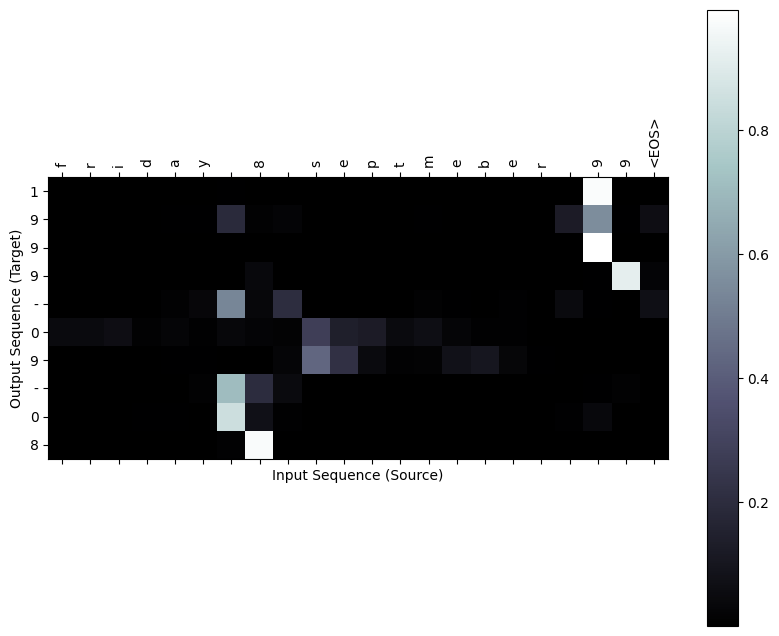

In [50]:
input_str = "Friday 8 septmeber 99"

# 1. Otteniamo gli indici (ci servono per le etichette del grafico)
# Assicurati che add_eos sia True se lo hai usato nel training
input_indices = input_vocab.encode(input_str, add_eos=True)

# 2. Predizione
prediction, attn_weights = predict_attn(input_str, enc_attn, dec_attn, input_vocab, output_vocab, device)

print(f'Input:  {input_str}')
print(f'Output: {prediction}')

# 3. Visualizzazione corretta
show_attention(input_indices, prediction, attn_weights, input_vocab)